# Ozone zeroing calibration

This notebook skips the first ozone data file and filters out rows where either sensor voltage has a magnitude greater than 2500 mV.

In [3]:
import csv
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

data_dir = Path.cwd()
if data_dir.name != 'Ozone_Calibration':
    data_dir = Path('/Users/tomw/Documents/VBUS/VBUS_Tall_Tower/Ozone_Calibration')

files = sorted(data_dir.glob('CSV_Ozone_0p5Hz*.dat'))
print(len(files))
files = files[:]  # Skip the first file in sorted filename order

records = []
for file_path in files:
    with file_path.open(newline='') as data_file:
        for row in csv.reader(data_file):
            if len(row) < 8:
                continue
            year, day, hhmm, seconds = map(int, row[:4])
            timestamp = datetime(year, 1, 1) + timedelta(
                days=day - 1,
                hours=hhmm // 100,
                minutes=hhmm % 100,
                seconds=seconds,
            )
            records.append({
                'timestamp': timestamp,
                'ozone1_mV': float(row[4]),
                'ozone2_mV': float(row[5]),
            })

data = pd.DataFrame(records).sort_values('timestamp')

# Keep the logger's original (pre-GPS-sync) clock on the plot.  A clock
# step larger than an hour is treated as a GPS synchronization, not a
# gap in the zeroing experiment.
data['plot_timestamp'] = data['timestamp']
expected_sample_period = pd.Timedelta(seconds=2)
timestamp_steps = data['timestamp'].diff()
clock_steps = timestamp_steps[timestamp_steps > pd.Timedelta(hours=1)]
if not clock_steps.empty:
    switch_timestamp = data.loc[clock_steps.index[0], 'timestamp']
    clock_correction = clock_steps.iloc[0] - expected_sample_period
    data.loc[data['timestamp'] >= switch_timestamp, 'plot_timestamp'] -= clock_correction
    print(f'Adjusted timestamps after {switch_timestamp} backward by {clock_correction}.')

before_filter = len(data)
valid = (data['ozone1_mV'].abs() <= 2500) & (data['ozone2_mV'].abs() <= 2500)
data = data.loc[valid].copy()

print('Files read:')
for file_path in files:
    print(f'  {file_path.name}')
print(f'Rows before filter: {before_filter:,}')
print(f'Rows removed: {before_filter - len(data):,}')
print(f'Rows retained: {len(data):,}')

3
Adjusted timestamps after 2026-09-08 20:09:42 backward by 0 days 06:00:00.
Files read:
  CSV_Ozone_0p5Hz7_2026_09_07_1414.dat
  CSV_Ozone_0p5Hz8_2026_09_08_1358.dat
  CSV_Ozone_0p5Hz9_2026_09_08_2028.dat
Rows before filter: 2,238
Rows removed: 0
Rows retained: 2,238


1222 median (13:28–13:38): 13.86 mV (n=279)
1504 median (13:55–14:10): 26.22 mV (n=451)
1234 median (14:30–14:40): 93.41 mV (n=301)
Saved plot to /Users/tomw/Documents/VBUS/VBUS_Tall_Tower/Ozone_Calibration/ozone_zeroing_voltage_filtered.png


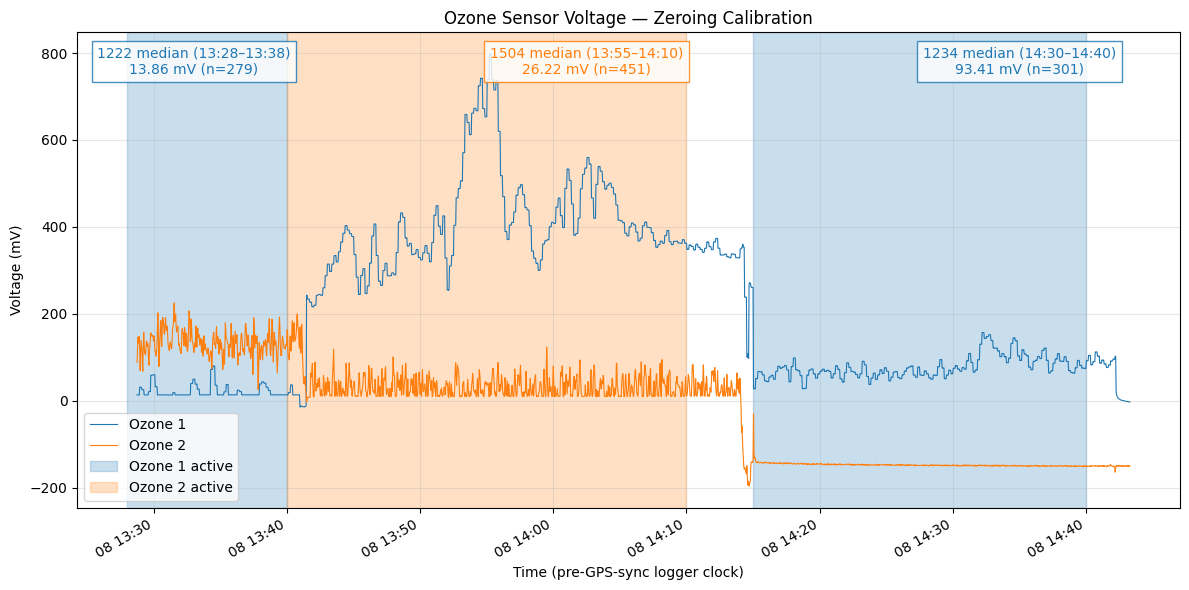

In [4]:
# Windows use the pre-GPS-sync clock, matching the experimental log.
calibration_day = data['plot_timestamp'].dt.normalize().min()
active_windows = [
    (
        calibration_day + pd.Timedelta(hours=13, minutes=28),
        calibration_day + pd.Timedelta(hours=13, minutes=40),
        'Ozone 1 active',
        'tab:blue',
    ),
    (
        calibration_day + pd.Timedelta(hours=13, minutes=40),
        calibration_day + pd.Timedelta(hours=14, minutes=10),
        'Ozone 2 active',
        'tab:orange',
    ),
    (
        calibration_day + pd.Timedelta(hours=14, minutes=15),
        calibration_day + pd.Timedelta(hours=14, minutes=40),
        'Ozone 1 active',
        'tab:blue',
    ),
]

median_windows = [
    (
        calibration_day + pd.Timedelta(hours=13, minutes=28),
        calibration_day + pd.Timedelta(hours=13, minutes=38),
        'ozone1_mV',
        '1222 median (13:28–13:38)',
        'tab:blue',
    ),
    (
        calibration_day + pd.Timedelta(hours=13, minutes=55),
        calibration_day + pd.Timedelta(hours=14, minutes=10),
        'ozone2_mV',
        '1504 median (13:55–14:10)',
        'tab:orange',
    ),
    (
        calibration_day + pd.Timedelta(hours=14, minutes=30),
        calibration_day + pd.Timedelta(hours=14, minutes=40),
        'ozone1_mV',
        '1234 median (14:30–14:40)',
        'tab:blue',
    ),
]

median_results = []
for start, end, column, label, color in median_windows:
    subset = data.loc[data['plot_timestamp'].between(start, end), column].dropna()
    median_mV = subset.median()
    sample_count = len(subset)
    median_results.append((start, end, label, color, median_mV, sample_count))
    print(f'{label}: {median_mV:.2f} mV (n={sample_count:,})')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data['plot_timestamp'], data['ozone1_mV'], label='Ozone 1', linewidth=0.8, zorder=2)
ax.plot(data['plot_timestamp'], data['ozone2_mV'], label='Ozone 2', linewidth=0.8, zorder=2)
for start, end, label, color in active_windows:
    ax.axvspan(start, end, color=color, alpha=0.24, label=label, zorder=1)
for start, end, label, color, median_mV, sample_count in median_results:
    midpoint = start + (end - start) / 2
    ax.text(
        midpoint,
        0.97,
        f'{label}\n{median_mV:.2f} mV (n={sample_count:,})',
        color=color,
        ha='center',
        va='top',
        transform=ax.get_xaxis_transform(),
        bbox={'facecolor': 'white', 'alpha': 0.82, 'edgecolor': color},
        zorder=3,
    )
ax.set_title('Ozone Sensor Voltage — Zeroing Calibration')
ax.set_xlabel('Time (pre-GPS-sync logger clock)')
ax.set_ylabel('Voltage (mV)')
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
legend_items = dict(zip(labels, handles))
ax.legend(legend_items.values(), legend_items.keys(), loc='lower left')
fig.autofmt_xdate()
fig.tight_layout()

output_path = data_dir / 'ozone_zeroing_voltage_filtered.png'
fig.savefig(output_path, dpi=150)
print(f'Saved plot to {output_path}')
plt.show()